# LSN Exercises 11
## Introduction to machine learning

Gabriele Borroni (14768A)

---



### The Prediction Problem

Consider a probabilistic process that gives rise to labeled data $(x,y)$. The data is generated by drawing samples from the equation

$$
    y_i= f(x_i) + \eta_i,
$$

where $f(x_i)$ is some fixed, but (possibly unknown) function, and $\eta_i$ is a Gaussian, uncorrelate noise variable such that

$$
\langle \eta_i \rangle=0 \\
\langle \eta_i \eta_j \rangle = \delta_{ij} \sigma
$$

We will refer to the $f(x_i)$ as the **true features** used to generate the data. 

To make predictions, we will consider a NN that depends on its parameters, weights and biases. The functions that the NN can model respresent the **model class** that we are using to try to model the data and make predictions.

To learn the parameters of the NN, we will train our models on a **training data set** and then test the effectiveness of the NN on a *different* dataset, the **validation data set**. The reason we must divide our data into a training and test dataset is that the point of machine learning is to make accurate predictions about new data we have not seen.

To measure our ability to predict, we will learn our parameters by fitting our training dataset and then making predictions on our test data set. One common measure of predictive  performance of our algorithm is to compare the predictions,$\{y_j^\mathrm{pred}\}$, to the true values $\{y_j\}$. A commonly employed measure for this is the sum of the mean square-error (MSE) on the test set:
$$
MSE= \frac{1}{N_\mathrm{test}}\sum_{j=1}^{N_\mathrm{test}} (y_j^\mathrm{pred}-y_j)^2
$$

### 1.1: linear fit
In the first part of the excercise, the function to be learned is the simplest: 
$$
f(x)=2x+1
$$

first, true function is generated and then the training dataset is obtained by adding some random (gaussian) noise

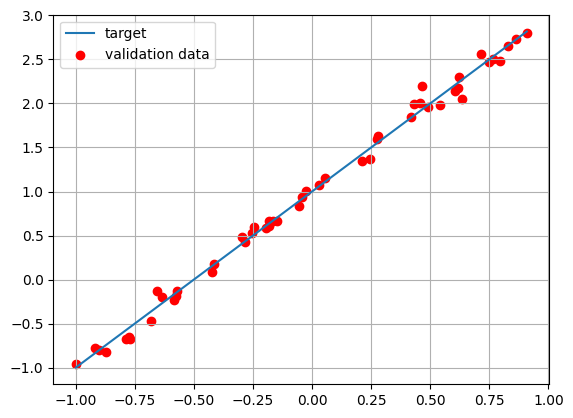

In [91]:
import numpy as np
import tensorflow as tf


# target parameters of f(x) = m*x + b
m = 2 # slope
b = 1 # intersect

# generate training inputs
np.random.seed(0)
x_train = np.random.uniform(-1, 1, 800)
x_valid = np.random.uniform(-1, 1, 50)
x_valid.sort()
y_target = m * x_valid + b # ideal (target) linear function

sigma = 0.1 # noise standard deviation
y_train = np.random.normal(m * x_train + b, sigma) # actual measures from which we want to guess regression parameters
y_valid = np.random.normal(m * x_valid + b, sigma)

# plot validation and target dataset
import matplotlib.pyplot as plt
plt.plot(x_valid, y_target, label='target')
plt.scatter(x_valid, y_valid, color='r', label='validation data')
plt.legend()
plt.grid(True)
plt.show()


In this first approach, the model used is the most basic possible: only one neuron (2 parameters) is sufficient to learn a linear function, because it already behaves like a linear function itself.

The training is performed on a batch size of 32 data points and in 50 epochs.

In [92]:
import tensorflow as tf
from tensorflow import keras



model0 = tf.keras.models.Sequential()
model0.add(tf.keras.layers.Dense(1, input_shape=(1,))) 

# compile the model choosing optimizer, loss and metrics objects
model0.compile(optimizer='sgd', loss='mse', metrics=['mse'])

# fit the model using training dataset
# over 10 epochs of 32 batch size each
# report training progress against validation data
history = model0.fit(x=x_train, y=y_train, 
          batch_size=32, epochs=50,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          validation_data=(x_valid, y_valid))


          # return weights and biases
model0.get_weights()



score = model0.evaluate(x_valid, y_valid, batch_size=32, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])


Epoch 1/50


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.9915 - mse: 3.9915 - val_loss: 3.0001 - val_mse: 3.0001
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.6448 - mse: 2.6448 - val_loss: 2.0215 - val_mse: 2.0215
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.8083 - mse: 1.8083 - val_loss: 1.3960 - val_mse: 1.3960
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2600 - mse: 1.2600 - val_loss: 0.9790 - val_mse: 0.9790
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8876 - mse: 0.8876 - val_loss: 0.6919 - val_mse: 0.6919
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6292 - mse: 0.6292 - val_loss: 0.4916 - val_mse: 0.4916
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4480 - mse: 0.4480 - val_loss: 0.3507 - val_mse: 0.3507
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3202 - mse: 0.3202 - val_loss: 0.2509 - val_mse: 0.2509
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2296 - mse: 0.2296 - va

In [3]:
#valuto il modello
score = model0.evaluate(x_valid, y_valid, batch_size=32, verbose=1)

print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0072 - mse: 0.0072

Test loss: 0.007181244902312756
Test accuracy: 0.007181244902312756


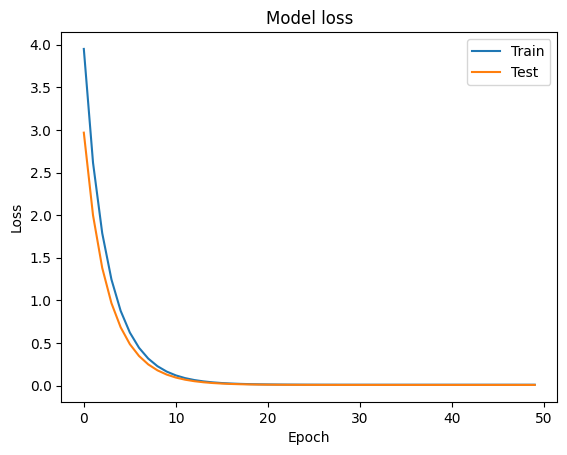

In [4]:
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.show()

### Exercise 11.2

Try to extend the model to obtain a reasonable fit of the following polynomial of order 3:

$$
f(x)=4-3x-2x^2+3x^3
$$
for $x \in [-1,1]$.

Of course, the one-neuron model isn't enough anymore, since the function isn't linear. The model is now extended to an MLP with two layers of 16 neurons each with Relu activation, and a single neuron output layer to generate the single valued predictions. 

The data is generated in the same way as before, and the training is performed on a batch size of 32 in 10 epochs. In this case, the optimizer used is Adam.
Adam combines the advantages of Momentum (keeps track of past gradients) and RMSProp (adapts learning rate per parameter). During the otpimization, it computes the exponential moving average of the gradients (first moment, like momentum), and the exponential moving average of the squared gradients (second moment, variance estimate).
These two moments are used to adapt the step size for each parameter dynamically, leading to a faster convergence.

The loss used is again MSE. 

Below training dataset and training output show the performance of the model.

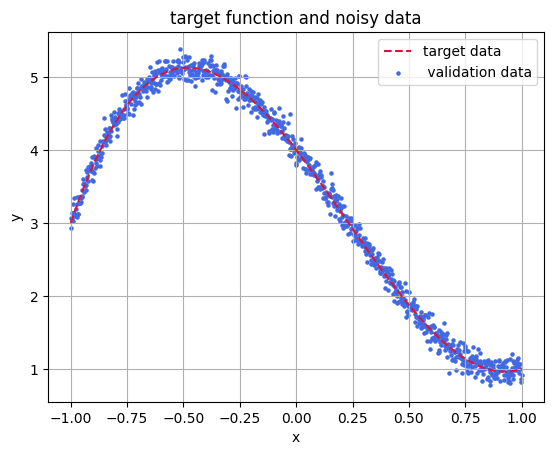

In [95]:
def f(x):
    return 4.0-4.0*x-2.0*x**2+3.0*x**3

def generate_data(x, sigma=0.1):
    #generate gaussian noise
    noise = np.random.normal(loc=0.0, scale=sigma, size=len(x))
    y= f(x)+noise
    return y

#generate training data
N=10000
x_train=np.linspace(-1,1,N)
y_train=generate_data(x_train)
x_val=np.linspace(-1,1,1000)
y_val=generate_data(x_val)

#target data to plot
xteo=np.linspace(-1,1,1000)
plt.plot(xteo, f(xteo), color='crimson', ls='--',label='target data' )
plt.scatter(x_val, y_val, s=5, color='royalblue', label=' validation data')
plt.grid(True)
plt.xlabel("x")
plt.ylabel("y")
plt.title("target function and noisy data")
plt.legend()
plt.show()




In [96]:

model=tf.keras.models.Sequential([ tf.keras.layers.Input(shape=(1,)),
                                  tf.keras.layers.Dense(16, activation='relu'),
                                  tf.keras.layers.Dense(16, activation='relu'),
                                  tf.keras.layers.Dense(1, activation='linear')])

model.summary()
model.compile(optimizer='Adam', loss='mse', metrics=['mse']) #mean absolute error
history=model.fit(x_train, y_train, batch_size=32, epochs=10, validation_data=(x_val, y_val))


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_56 (Dense)                │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 697us/step - loss: 4.2415 - mse: 4.2415 - val_loss: 0.5289 - val_mse: 0.5289
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 452us/step - loss: 0.2745 - mse: 0.2745 - val_loss: 0.1299 - val_mse: 0.1299
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 443us/step - loss: 0.0813 - mse: 0.0813 - val_loss: 0.0519 - val_mse: 0.0519
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step - loss: 0.0373 - mse: 0.0373 - val_loss: 0.0285 - val_mse: 0.0285
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 440us/step - loss: 0.0231 - mse: 0.0231 - val_loss: 0.0201 - val_mse: 0.0201
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 438us/step - loss: 0.0174 - mse: 0.0174 - val_loss: 0.0170 - val_mse: 0.0170
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 432us/step - loss: 0.0147 - mse: 0.0147 - val_loss: 0.0143 - val_mse: 0.0143
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 429us/step - loss: 0.0133 - mse: 0.0133 - val_loss: 0.0132 - val_mse: 0.0132
Epoch 9/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 

In [97]:
# evaluate model
score = model.evaluate(x_val, y_val, batch_size=32, verbose=1) #valuta il modello sui valid (che non ha mai visto prima)
#verbose indica il progresso

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 552us/step - loss: 0.0124 - mse: 0.0124

Test loss: 0.012381672859191895
Test accuracy: 0.012381672859191895


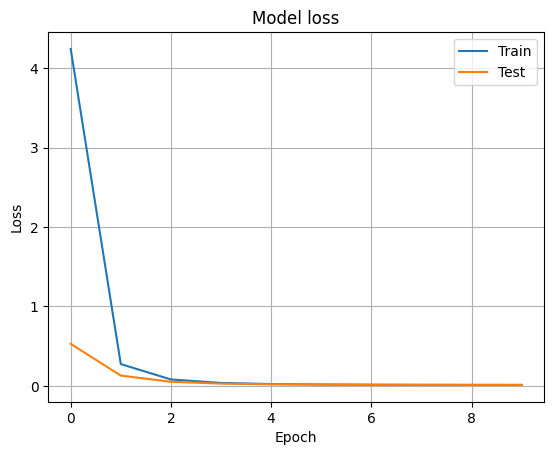

In [98]:
import matplotlib.pyplot as plt
# look into training history
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.grid(True)
plt.show()

In this section, the model’s ability to generalize was tested by evaluating it on intervals of $f(x)$ different from those used during training.  
While the model performs accurately within the training range, its predictions fail to generalize outside of it.  

This limitation is rooted in the very nature of neural networks: they are effective interpolators within the domain of the training data, but outside that range they tend to produce unreliable outputs, often manifesting as random fluctuations or flattened predictions.  

Increasing complexity (by adding layers or neurons) enhances the model’s ability to fit the training data and reduces training error.  
However, greater complexity does not guarantee improved generalization, particularly outside the training domain.  
Neural networks are strong interpolators but weak extrapolators: their predictive power is fundamentally tied to the distribution of the data on which they are trained.  
Achieving good generalization requires not only an appropriately sized model but also training data that adequately cover the range where predictions are expected.


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


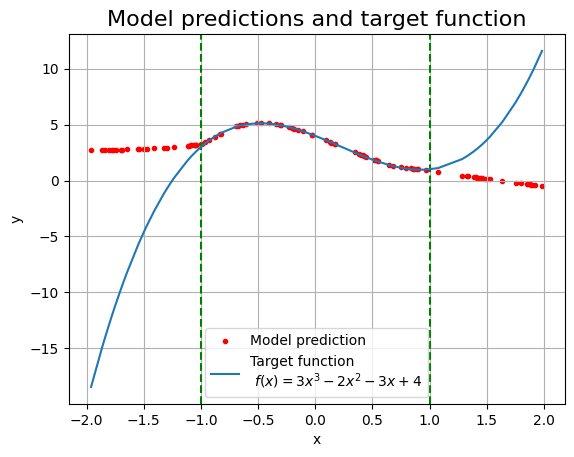

In [99]:

# generate predictions
x_predicted = np.random.uniform(-2, 2, 100) 
y_predicted = model.predict(x_predicted)

plt.scatter(x_predicted, y_predicted, marker = ".", color='r', label = "Model prediction")
x_predicted.sort()
y_target_ext = f(x_predicted)
plt.axvline(1., color = 'g', linestyle = '--')
plt.axvline(-1., color = 'g', linestyle = '--')
plt.plot(x_predicted, y_target_ext, label = "Target function\n $f(x) = 3x^3 - 2x^2 - 3x + 4$")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Model predictions and target function", fontsize = 16)
plt.grid(True)
plt.legend()
plt.show()

### Exercise 11.3
  
Try to extend the model to fit a simple trigonometric 2D function such as $f(x,y) = \sin(x^2+y^2)$ in the range $x \in [-3/2,3/2]$ and $y \in [-3/2,3/2]$.

For this task, the model built consists in two layers of 64 neurons each, and a final otput layer with a single neuron.

Also for this case, the best activation function found was the Relu, which performed slightly better than the SeLu one, which was the second best activation function that has been found.

The optimizer used is again Adam with loss MSE, since the task was similar to the previous one. 

Generated data, training and model performance are shown below.

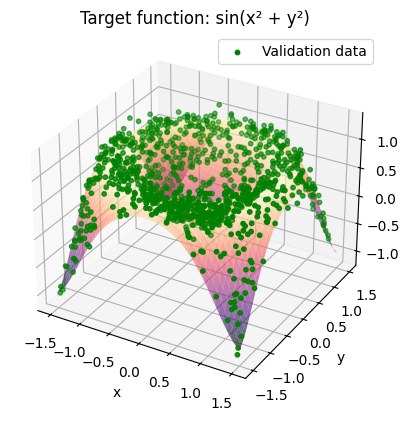

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  

def f(x, y):
    return np.sin(x**2 + y**2)

def gen_data(X, Y, sigma=0.1):
    noise = np.random.normal(loc=0.0, scale=sigma, size=X.shape)
    return f(X, Y) + noise

# surface grid
x = np.linspace(-1.5, 1.5, 100)
y = np.linspace(-1.5, 1.5, 100)
X_plot, Y_plot = np.meshgrid(x, y)


Z_plot = f(X_plot, Y_plot)

n_val = 1000
x_val = np.random.uniform(-1.5, 1.5, n_val)
y_val = np.random.uniform(-1.5, 1.5, n_val)
z_val = gen_data(x_val, y_val)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# target function
ax.plot_surface(X_plot, Y_plot, Z_plot, cmap='magma', alpha=0.6)

# noise data
ax.scatter(x_val, y_val, z_val, color='green', s=10, label='Validation data')


ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Target function: sin(x² + y²)')
ax.legend()

plt.show()


In [101]:

n_train=10000
x_train = np.random.uniform(-1.5, 1.5, n_train)
y_train = np.random.uniform(-1.5, 1.5, n_train)
z_train = gen_data(x_train, y_train)

model3d=tf.keras.models.Sequential([
                        tf.keras.layers.Input(shape=(2,)),
                        tf.keras.layers.Dense(64, activation='relu'),
                        tf.keras.layers.Dense(64, activation='relu'),
                        tf.keras.layers.Dense(1, activation='linear')
])
model3d.summary()
model3d.compile(optimizer='Adam', loss='mse', metrics=['mae'])
X_train = np.column_stack((x_train, y_train))  # shape (N,2)
X_val = np.column_stack((x_val, y_val))  


history=model3d.fit(X_train, z_train, batch_size=32, epochs=20, validation_data=(X_val, z_val))

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_59 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 671us/step - loss: 0.1650 - mae: 0.3047 - val_loss: 0.1290 - val_mae: 0.2678
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 451us/step - loss: 0.0996 - mae: 0.2377 - val_loss: 0.0670 - val_mae: 0.1859
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 445us/step - loss: 0.0398 - mae: 0.1454 - val_loss: 0.0219 - val_mae: 0.1133
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 443us/step - loss: 0.0171 - mae: 0.1019 - val_loss: 0.0135 - val_mae: 0.0925
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step - loss: 0.0132 - mae: 0.0906 - val_loss: 0.0120 - val_mae: 0.0876
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step - loss: 0.0121 - mae: 0.0877 - val_loss: 0.0113 - val_mae: 0.0856
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 506us/step - loss: 0.0118 - mae: 0.0864 - val_loss: 0.0120 - val_mae: 0.0878
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 530us/step - loss: 0.0115 - mae: 0.0860 - val_loss: 0.0120 - val_mae: 0.0883
Epoch 9/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 570us/step


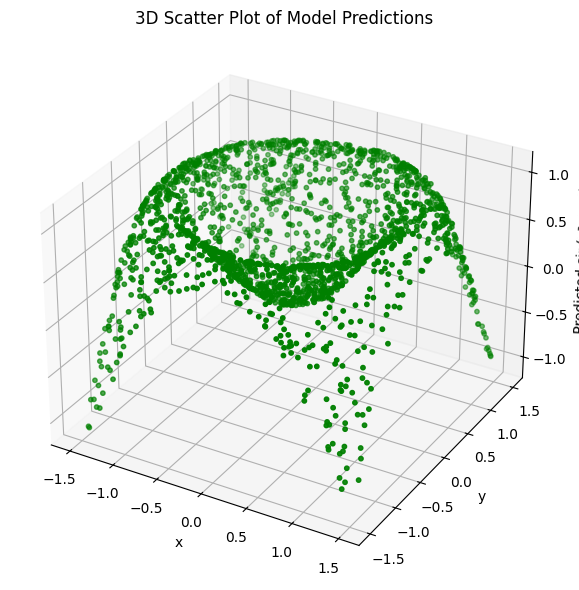

In [90]:
x_p = np.random.uniform(-3./2., 3./2., 2000)
y_p = np.random.uniform(-3./2., 3./2., 2000)
X_p=np.column_stack((x_p, y_p))
z_p = model3d.predict(X_p)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter points: x, y, prediction
ax.scatter(X_p[:, 0], X_p[:, 1], z_p.flatten(), c='green', s=10)

# Labels and title
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('Predicted sin(x² + y²)')
ax.set_title('3D Scatter Plot of Model Predictions')


plt.tight_layout()
plt.show()